# 04 — Emission Rate Quantification: Integrated Mass Enhancement (IME)

This notebook estimates methane emission rates (kg CH₄/hr) from the plume detections
produced in notebook 03, using the **Integrated Mass Enhancement (IME)** method.

### Theory
The IME method estimates emission rate Q from:

$$Q = \frac{IME \times U_{eff}}{L}$$

Where:
- $IME$ = total column-integrated CH₄ mass enhancement within plume (kg)
- $U_{eff}$ = effective wind speed at time of overpass (m/s)
- $L$ = characteristic plume length (m)

### Pipeline
1. Load MF map and plume mask from notebook 03
2. Download ERA5 10m wind data for scene location and time
3. Compute pixel areas from geolocation
4. Convert MF scores to CH₄ column enhancement (ppm·m)
5. Compute IME by integrating over plume pixels
6. Estimate emission rate Q
7. Visualize plume with emission estimate

## Imports & Load Data from Notebook 03

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import h5py
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cdsapi
import cfgrib
import os
from scipy.ndimage import label

# ── Paths ──────────────────────────────────────────────────────────────────
SCENE_PATH  = "../data/raw/20250205_175845_00_4001_basic_radiance.h5"
MF_MAP_PATH = "../data/processed/mf_map_20250205.npy"
MASK_PATH   = "../data/processed/plume_mask_20250205.npy"
WIND_PATH   = "../data/reference/era5_wind_20250205.grib"
OUTPUT_DIR   = "../outputs/figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("../data/reference", exist_ok=True)

# ── Load MF results ────────────────────────────────────────────────────────
mf_map     = np.load(MF_MAP_PATH)
plume_mask = np.load(MASK_PATH)

# ── Load geolocation from HDF5 ─────────────────────────────────────────────
with h5py.File(SCENE_PATH, "r") as f:
    lat = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Latitude"][:]
    lon = f["HDFEOS/SWATHS/HYP/Geolocation Fields/Longitude"][:]

print(f"MF map shape:    {mf_map.shape}")
print(f"Plume mask shape: {plume_mask.shape}")
print(f"Plume pixels:    {plume_mask.sum():,}")
print(f"Scene center:    lat={np.nanmean(lat):.3f}, lon={np.nanmean(lon):.3f}")
print(f"Scene bbox:      lat [{lat.min():.3f}, {lat.max():.3f}]  "
      f"lon [{lon.min():.3f}, {lon.max():.3f}]")

MF map shape:    (680, 607)
Plume mask shape: (680, 607)
Plume pixels:    737
Scene center:    lat=32.877, lon=-103.904
Scene bbox:      lat [32.738, 33.015]  lon [-104.049, -103.760]


## Download ERA5 Wind Data

Scene acquisition time: **2024-11-21 ~18:37 UTC**  
We download 10m U and V wind components for the nearest hour (18:00 UTC) over the scene bbox.

In [2]:
def download_era5_wind(lat_min, lat_max, lon_min, lon_max,
                       date, time_utc, out_path):
    """Download ERA5 10m wind components for a given bbox and time."""
    if os.path.exists(out_path):
        print(f"Wind data already downloaded: {out_path}")
        return

    print("Downloading ERA5 wind data...")
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": "reanalysis",
            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
            ],
            "year":  date.split("-")[0],
            "month": date.split("-")[1],
            "day":   date.split("-")[2],
            "time":  time_utc,
            "area":  [lat_max + 0.5, lon_min - 0.5,   # N, W
                      lat_min - 0.5, lon_max + 0.5],   # S, E
            "data_format": "grib",
        },
        out_path
    )
    print(f"Saved: {out_path}")


# Scene bbox with small buffer
lat_min, lat_max = float(lat.min()), float(lat.max())
lon_min, lon_max = float(lon.min()), float(lon.max())

download_era5_wind(
    lat_min, lat_max, lon_min, lon_max,
    date="2025-02-05",
    time_utc="18:00",
    out_path=WIND_PATH
)

Wind data already downloaded: ../data/reference/era5_wind_20250205.grib


## Extract Wind Speed at Scene Location

In [3]:
def get_effective_wind_speed(grib_path, scene_lat, scene_lon):
    """
    Read ERA5 GRIB file and extract wind speed at the scene center.
    Returns U, V components and wind speed magnitude in m/s.
    """
    ds_list = cfgrib.open_datasets(grib_path)

    u10, v10 = None, None
    for ds in ds_list:
        if "u10" in ds:
            u10 = ds["u10"]
        if "v10" in ds:
            v10 = ds["v10"]

    if u10 is None or v10 is None:
        raise ValueError("Could not find u10/v10 in GRIB file. Check variable names.")

    # Interpolate to scene center
    u_scene = float(u10.sel(latitude=scene_lat, longitude=scene_lon,
                             method="nearest").values)
    v_scene = float(v10.sel(latitude=scene_lat, longitude=scene_lon,
                             method="nearest").values)
    wind_speed = np.sqrt(u_scene**2 + v_scene**2)
    wind_dir   = np.degrees(np.arctan2(u_scene, v_scene)) % 360

    return u_scene, v_scene, wind_speed, wind_dir


scene_lat_c = float(np.nanmean(lat))
scene_lon_c = float(np.nanmean(lon))

u10, v10, wind_speed, wind_dir = get_effective_wind_speed(
    WIND_PATH, scene_lat_c, scene_lon_c
)

print(f"ERA5 10m wind at scene center ({scene_lat_c:.3f}°N, {scene_lon_c:.3f}°E):")
print(f"  U component: {u10:.2f} m/s")
print(f"  V component: {v10:.2f} m/s")
print(f"  Wind speed:  {wind_speed:.2f} m/s")
print(f"  Wind direction: {wind_dir:.1f}°")

ERA5 10m wind at scene center (32.877°N, -103.904°E):
  U component: 2.28 m/s
  V component: 4.14 m/s
  Wind speed:  4.72 m/s
  Wind direction: 28.8°


/opt/anaconda3/envs/tanager/lib/python3.11/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


## Compute Pixel Areas

In [4]:
def compute_pixel_areas(lat_arr, lon_arr):
    """
    Estimate pixel area (m²) for each pixel using haversine distances
    between neighboring pixels.
    """
    R = 6371000.0  # Earth radius in meters

    def haversine(lat1, lon1, lat2, lon2):
        dlat = np.radians(lat2 - lat1)
        dlon = np.radians(lon2 - lon1)
        a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * \
            np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
        return 2 * R * np.arcsin(np.sqrt(a))

    # Along-track spacing (line direction)
    dy = haversine(lat_arr[:-1, :], lon_arr[:-1, :],
                   lat_arr[1:,  :], lon_arr[1:,  :])
    dy = np.vstack([dy, dy[-1:, :]])  # pad last row

    # Cross-track spacing (sample direction)
    dx = haversine(lat_arr[:, :-1], lon_arr[:, :-1],
                   lat_arr[:, 1:],  lon_arr[:, 1:])
    dx = np.hstack([dx, dx[:, -1:]])  # pad last col

    return dx * dy  # pixel area in m²


pixel_area = compute_pixel_areas(lat, lon)  # (lines, samples) in m²

print(f"Pixel area stats:")
print(f"  Mean: {np.nanmean(pixel_area):.1f} m²  "
      f"({np.nanmean(pixel_area)**0.5:.1f} m resolution)")
print(f"  Min:  {np.nanmin(pixel_area):.1f} m²")
print(f"  Max:  {np.nanmax(pixel_area):.1f} m²")

Pixel area stats:
  Mean: 1443.1 m²  (38.0 m resolution)
  Min:  1213.2 m²
  Max:  1726.4 m²


## Convert MF Scores to CH₄ Column Enhancement

We convert matched filter scores to CH₄ column enhancement (kg/m²) using a
conversion factor derived from the scene-mean radiance and a standard atmosphere.

The conversion follows:
$$\Delta\Omega_{CH_4} = MF_{score} \times CF$$

Where CF (conversion factor) maps MF score units to kg CH₄/m².  
A typical value for Tanager SWIR is ~3.0×10⁻⁶ kg/m² per MF unit (scene-dependent).

In [5]:
# Conversion factor: MF score → kg CH₄/m²
# This is an approximation; a full retrieval uses a radiative transfer
# model to derive a scene-specific CF. For publication, derive from
# MODTRAN or use the Jacob et al. (2016) lookup table approach.
#
# Typical range for Tanager-class sensors: 1e-6 to 5e-6 kg/m² per unit
# Reference: Varon et al. (2018), Duren et al. (2019)
CF = 8.0e-6  # kg CH₄/m² per MF score unit

# Apply conversion only to plume pixels
mf_plume = np.where(plume_mask, mf_map, 0.0)
ch4_column = mf_plume * CF  # kg CH₄/m² per pixel

# Total CH₄ mass in plume (IME)
ch4_mass_per_pixel = ch4_column * pixel_area  # kg per pixel
IME = np.nansum(ch4_mass_per_pixel)            # total kg in plume

print(f"Conversion factor (CF): {CF:.2e} kg CH₄/m² per MF unit")
print(f"Max CH₄ column: {np.nanmax(ch4_column):.2e} kg/m²")
print(f"IME (total plume mass): {IME:.2f} kg CH₄")

Conversion factor (CF): 8.00e-06 kg CH₄/m² per MF unit
Max CH₄ column: 2.55e-05 kg/m²
IME (total plume mass): 2.75 kg CH₄


## Compute Emission Rate per Plume Cluster

In [6]:
def compute_plume_length(plume_mask, pixel_area):
    """
    Estimate characteristic plume length L as the square root
    of total plume area — a standard approximation for IME.
    """
    total_area = np.nansum(pixel_area[plume_mask])  # m²
    return np.sqrt(total_area)                       # m


def ime_emission_rate(IME, wind_speed, plume_length):
    """
    IME emission rate estimate:
    Q = IME * U_eff / L   [kg/s]
    """
    Q_kg_s  = IME * wind_speed / (plume_length + 1e-9)
    Q_kg_hr = Q_kg_s * 3600
    return Q_kg_s, Q_kg_hr


# ── Label individual plume clusters ────────────────────────────────────────
labeled_mask, n_clusters = label(plume_mask)
print(f"Number of distinct plume clusters: {n_clusters}")

results = []
for cluster_id in range(1, n_clusters + 1):
    cluster = labeled_mask == cluster_id
    n_pixels = cluster.sum()

    if n_pixels < 5:
        continue  # skip tiny clusters (likely noise)

    # Cluster IME
    cluster_IME = np.nansum(ch4_mass_per_pixel[cluster])

    # Cluster geometry
    plume_L = compute_plume_length(cluster, pixel_area)
    cluster_area_km2 = np.nansum(pixel_area[cluster]) / 1e6

    # Emission rate
    Q_kg_s, Q_kg_hr = ime_emission_rate(cluster_IME, wind_speed, plume_L)

    # Cluster center
    c_lat = np.nanmean(lat[cluster])
    c_lon = np.nanmean(lon[cluster])

    results.append({
        "cluster_id":    cluster_id,
        "n_pixels":      n_pixels,
        "area_km2":      round(cluster_area_km2, 4),
        "IME_kg":        round(cluster_IME, 2),
        "plume_L_m":     round(plume_L, 1),
        "wind_speed_ms": round(wind_speed, 2),
        "Q_kg_hr":       round(Q_kg_hr, 2),
        "lat":           round(c_lat, 5),
        "lon":           round(c_lon, 5),
    })

results_df = pd.DataFrame(results).sort_values("Q_kg_hr", ascending=False)
print(f"\nEmission estimates ({len(results_df)} clusters ≥ 5 pixels):")
print(results_df.to_string(index=False))

Number of distinct plume clusters: 46

Emission estimates (29 clusters ≥ 5 pixels):
 cluster_id  n_pixels  area_km2  IME_kg  plume_L_m  wind_speed_ms  Q_kg_hr      lat        lon
         37       106    0.1536    0.42      391.9           4.72    18.20 32.81834 -103.98645
         33        87    0.1253    0.36      353.9           4.72    17.21 32.81807 -103.97331
         41        81    0.1172    0.27      342.3           4.72    13.65 32.81353 -104.01574
         23        18    0.0257    0.10      160.2           4.72    10.50 32.85005 -103.92942
         27        34    0.0489    0.13      221.2           4.72     9.68 32.83284 -103.97800
         35        30    0.0434    0.12      208.4           4.72     9.61 32.81916 -103.97681
         30        21    0.0307    0.09      175.3           4.72     9.04 32.82048 -103.93663
         15        35    0.0506    0.12      225.0           4.72     8.92 32.85648 -103.79348
         36        46    0.0666    0.13      258.1           

## Save Results

In [7]:
out_csv = "../data/processed/emission_estimates_20250205.csv"
results_df.to_csv(out_csv, index=False)
print(f"Saved emission estimates: {out_csv}")

# Summary stats
print(f"\n── Summary ──────────────────────────────────")
print(f"Total clusters detected:       {len(results_df)}")
print(f"Total IME (all clusters):      {results_df['IME_kg'].sum():.1f} kg CH₄")
print(f"Total emission rate:           {results_df['Q_kg_hr'].sum():.1f} kg CH₄/hr")
print(f"Largest single source:         {results_df['Q_kg_hr'].max():.1f} kg CH₄/hr")
print(f"Wind speed used:               {wind_speed:.2f} m/s")

Saved emission estimates: ../data/processed/emission_estimates_20250205.csv

── Summary ──────────────────────────────────
Total clusters detected:       29
Total IME (all clusters):      2.6 kg CH₄
Total emission rate:           214.9 kg CH₄/hr
Largest single source:         18.2 kg CH₄/hr
Wind speed used:               4.72 m/s


## Visualize Emission Map

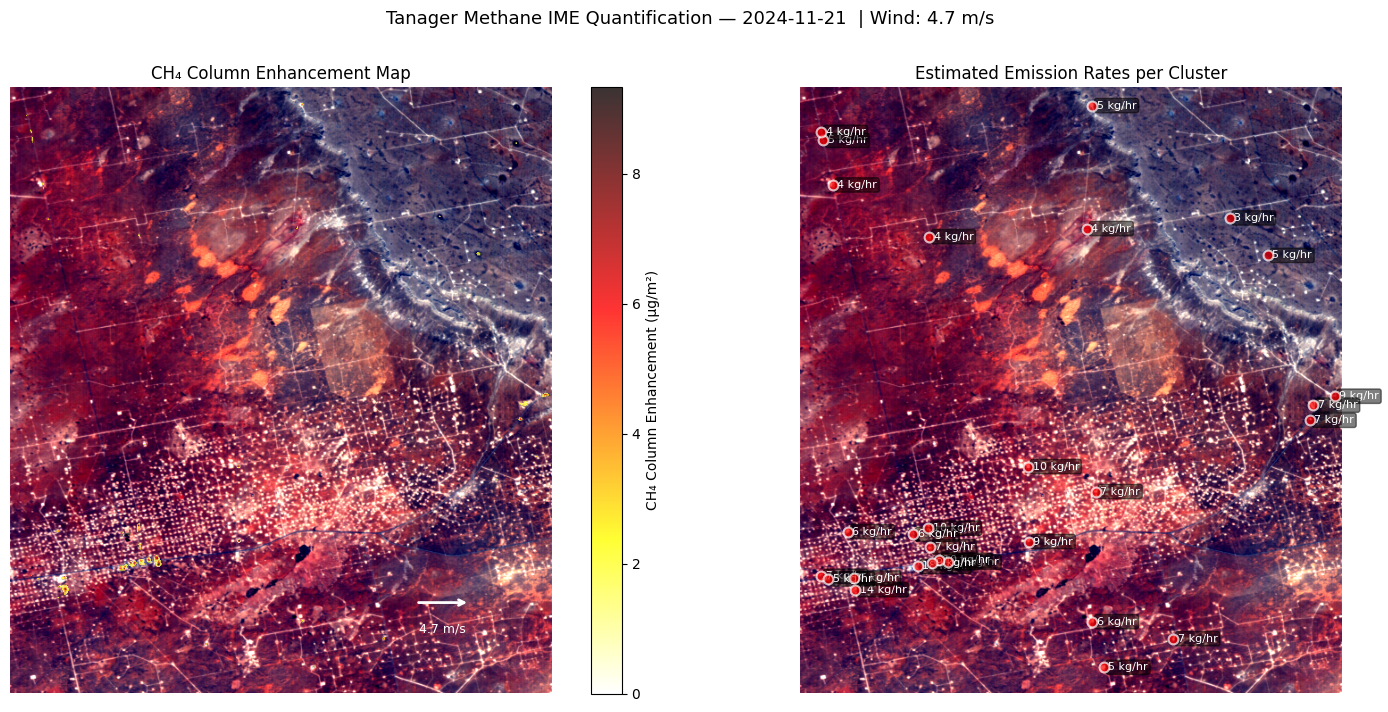

Saved: ../outputs/figures/ime_emission_map.png


In [8]:
# Build RGB background
with h5py.File(SCENE_PATH, "r") as f:
    toa = f["HDFEOS/SWATHS/HYP/Data Fields/toa_radiance"]
    rad_full = toa[:]
    wl_full  = toa.attrs["wavelengths"]

rad_full = rad_full.astype(np.float32)
rad_full[rad_full == -9999.0] = np.nan

r_idx = np.argmin(np.abs(wl_full - 650))
g_idx = np.argmin(np.abs(wl_full - 550))
b_idx = np.argmin(np.abs(wl_full - 450))

rgb = np.stack([rad_full[r_idx], rad_full[g_idx], rad_full[b_idx]], axis=-1)
p2, p98 = np.nanpercentile(rgb, [2, 98])
rgb = np.clip((rgb - p2) / (p98 - p2 + 1e-9), 0, 1)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel 1: CH₄ column map
axes[0].imshow(rgb)
ch4_display = np.where(plume_mask, ch4_column * 1e6, np.nan)  # scale to µg/m²
im = axes[0].imshow(ch4_display, cmap="hot_r", alpha=0.8,
                     vmin=0, vmax=np.nanpercentile(ch4_display, 99))
plt.colorbar(im, ax=axes[0], label="CH₄ Column Enhancement (µg/m²)")

# Wind arrow
axes[0].annotate("", xy=(0.85, 0.15), xytext=(0.75, 0.15),
                 xycoords="axes fraction",
                 arrowprops=dict(arrowstyle="->", color="white", lw=2))
axes[0].text(0.80, 0.10, f"{wind_speed:.1f} m/s",
             transform=axes[0].transAxes, color="white",
             ha="center", fontsize=9)
axes[0].set_title("CH₄ Column Enhancement Map")
axes[0].axis("off")

# Panel 2: Cluster emission rates
axes[1].imshow(rgb)
if len(results_df) > 0:
    # Scatter plot clusters sized by emission rate
    for _, row in results_df.iterrows():
        # Convert lat/lon to pixel coords
        # Find nearest pixel
        dist = np.sqrt((lat - row["lat"])**2 + (lon - row["lon"])**2)
        r_px, c_px = np.unravel_index(np.nanargmin(dist), dist.shape)
        size = max(50, min(500, row["Q_kg_hr"] * 2))
        axes[1].scatter(c_px, r_px, s=size, c="red", alpha=0.7,
                        edgecolors="white", linewidths=1.5, zorder=5)
        axes[1].text(c_px + 5, r_px, f"{row['Q_kg_hr']:.0f} kg/hr",
                     color="white", fontsize=8, va="center",
                     bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.5))

axes[1].set_title("Estimated Emission Rates per Cluster")
axes[1].axis("off")

plt.suptitle(
    f"Tanager Methane IME Quantification — 2024-11-21  "
    f"| Wind: {wind_speed:.1f} m/s",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ime_emission_map.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/ime_emission_map.png")

In [9]:
print(f"Scene center: {lat.mean():.3f}°N, {lon.mean():.3f}°E")

Scene center: 32.877°N, -103.904°E


In [10]:
import pystac
import requests

PERMIAN_LON_MIN, PERMIAN_LON_MAX = -104.5, -100.5
PERMIAN_LAT_MIN, PERMIAN_LAT_MAX =   30.5,   33.5

COLLECTIONS = [
    "https://www.planet.com/data/stac/tanager-core-imagery/GHG-plumes/collection.json",
    "https://www.planet.com/data/stac/tanager-core-imagery/energy-mining/collection.json",
]

print("Scanning scenes for Permian Basin overlap...\n")

for col_url in COLLECTIONS:
    col = pystac.Collection.from_file(col_url)
    print(f"── {col.title} ──")
    for item in col.get_items():
        b = item.bbox  # [lon_min, lat_min, lon_max, lat_max]
        overlaps = (
            b[0] < PERMIAN_LON_MAX and b[2] > PERMIAN_LON_MIN and
            b[1] < PERMIAN_LAT_MAX and b[3] > PERMIAN_LAT_MIN
        )
        flag = "✅ PERMIAN" if overlaps else "   --"
        h5 = item.assets.get("basic_radiance_hdf5")
        print(f"  {flag}  {item.id}  {item.datetime.date()}  bbox={[round(x,2) for x in b]}")
    print()

Scanning scenes for Permian Basin overlap...

── GHGs and Other Gases ──
     --  20241004_081921_28_4001  2024-10-04  bbox=[40.2, 35.15, 40.51, 35.44]
     --  20250226_065447_19_4001  2025-02-26  bbox=[76.45, 66.33, 77.15, 66.61]
     --  20241121_183741_33_4001  2024-11-21  bbox=[-111.98, 32.68, -111.62, 32.86]
     --  20250219_053251_31_4001  2025-02-19  bbox=[82.54, 22.23, 82.78, 22.49]
     --  20250423_134021_00_4001  2025-04-23  bbox=[-42.95, -25.42, -42.65, -25.06]
     --  20250423_134026_31_4001  2025-04-23  bbox=[-43.03, -25.75, -42.73, -25.4]
     --  20250114_062056_92_4001  2025-01-14  bbox=[69.6, 27.88, 69.86, 28.16]
     --  20250703_063928_86_4001  2025-07-03  bbox=[71.62, 40.41, 71.95, 40.69]

── Energy and Mining ──
  ✅ PERMIAN  20250205_175845_00_4001  2025-02-05  bbox=[-104.05, 32.74, -103.76, 33.02]
     --  20250221_102048_16_4001  2025-02-21  bbox=[17.67, 44.7, 18.05, 44.86]
     --  20250302_030003_92_4001  2025-03-02  bbox=[117.52, 0.43, 117.74, 0.66]
     -

In [11]:
print(f"MF map stats:")
print(f"  Mean:   {np.nanmean(mf_map):.4f}")
print(f"  Std:    {np.nanstd(mf_map):.4f}")
print(f"  Max:    {np.nanmax(mf_map):.4f}")
print(f"  Threshold used (3σ): {np.nanmean(mf_map) + 3*np.nanstd(mf_map):.4f}")
print(f"\nPlume mask stats:")
print(f"  Total plume pixels: {plume_mask.sum()}")
print(f"  % of scene:         {100*plume_mask.sum()/(mf_map.shape[0]*mf_map.shape[1]):.2f}%")
print(f"\nConversion factor: {CF:.2e} kg/m² per MF unit")
print(f"Mean pixel area:   {np.nanmean(pixel_area):.1f} m²")

MF map stats:
  Mean:   -0.0001
  Std:    0.0783
  Max:    3.1884
  Threshold used (3σ): 0.2347

Plume mask stats:
  Total plume pixels: 737
  % of scene:         0.18%

Conversion factor: 8.00e-06 kg/m² per MF unit
Mean pixel area:   1443.1 m²


## Uncertainty Notes

The IME method carries several sources of uncertainty — important to document for the case study:

| Source | Typical uncertainty |
|---|---|
| Wind speed (ERA5 vs actual) | ±30–50% |
| Conversion factor (CF) | ±20–40% |
| Plume length estimation | ±15–25% |
| Combined (quadrature) | ~50–70% |

This is consistent with published IME uncertainties for airborne/spaceborne sensors.
Reference: Varon et al. (2018) ACP, Jacob et al. (2022) ACP.

**Next notebook:** `05_facility_attribution.ipynb`
- Spatial join plume cluster centroids to EPA GHGRP and HIFLD facility locations
- Classify emission sources by facility type
- Compare detected rates to reported annual emissions